In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

df = pd.read_csv('../data/cleaned/main_dataset.csv')
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
colors = {'Winter':'#5B8DB8','Spring':'#6DBF8A','Summer':'#F5A623','Fall':'#E07B5A'}
print("Loaded!", df.shape)

Loaded! (545604, 21)


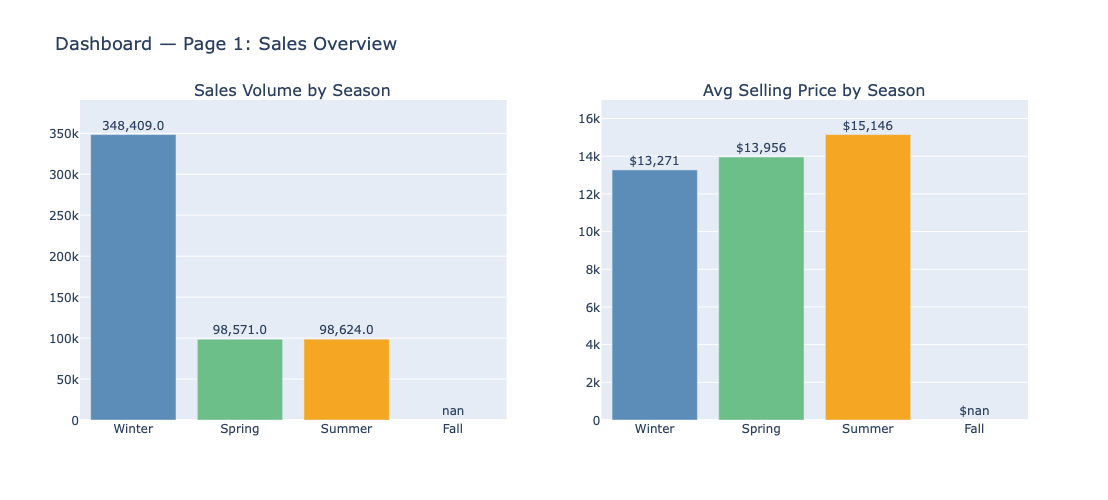

In [2]:
season_counts = df['season'].value_counts().reindex(season_order)
avg_prices = df.groupby('season')['sellingprice'].mean().reindex(season_order)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Sales Volume by Season', 'Avg Selling Price by Season')
)

fig.add_trace(go.Bar(
    x=season_counts.index,
    y=season_counts.values,
    marker_color=[colors[s] for s in season_order],
    name='Sales Volume',
    text=[f'{v:,}' for v in season_counts.values],
    textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=avg_prices.index,
    y=avg_prices.values,
    marker_color=[colors[s] for s in season_order],
    name='Avg Price',
    text=[f'${v:,.0f}' for v in avg_prices.values],
    textposition='outside'
), row=1, col=2)

fig.update_layout(
    title_text='Dashboard — Page 1: Sales Overview',
    title_font_size=18,
    showlegend=False,
    height=500
)
fig.write_html('../outputs/page1_overview.html')
fig.show()

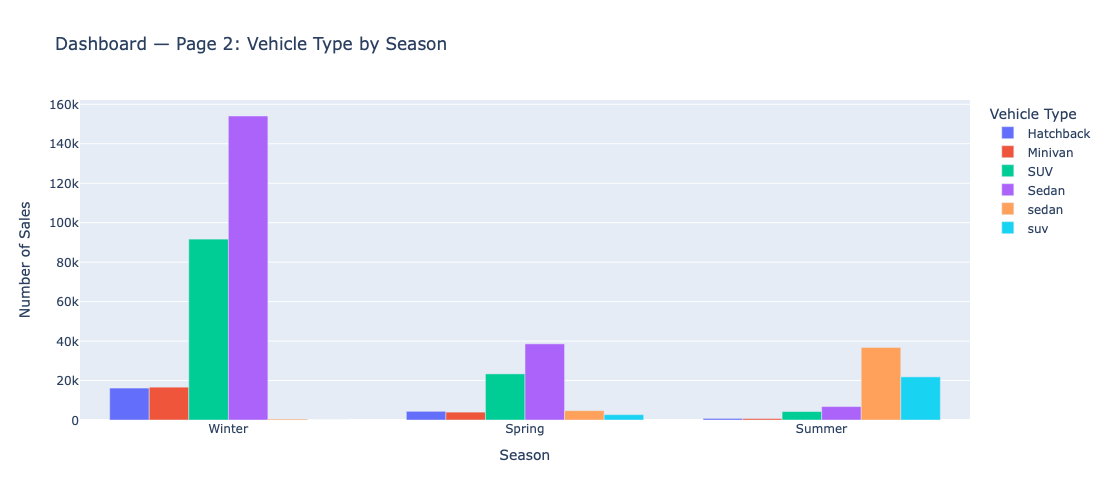

In [3]:
top_bodies = df['body'].value_counts().head(6).index
df_top = df[df['body'].isin(top_bodies)]
pivot = df_top.groupby(['season','body']).size().reset_index(name='count')

fig = px.bar(
    pivot, x='season', y='count', color='body',
    barmode='group',
    category_orders={'season': season_order},
    title='Dashboard — Page 2: Vehicle Type by Season',
    labels={'count':'Number of Sales','season':'Season','body':'Vehicle Type'},
    height=500
)
fig.write_html('../outputs/page2_vehicle_types.html')
fig.show()

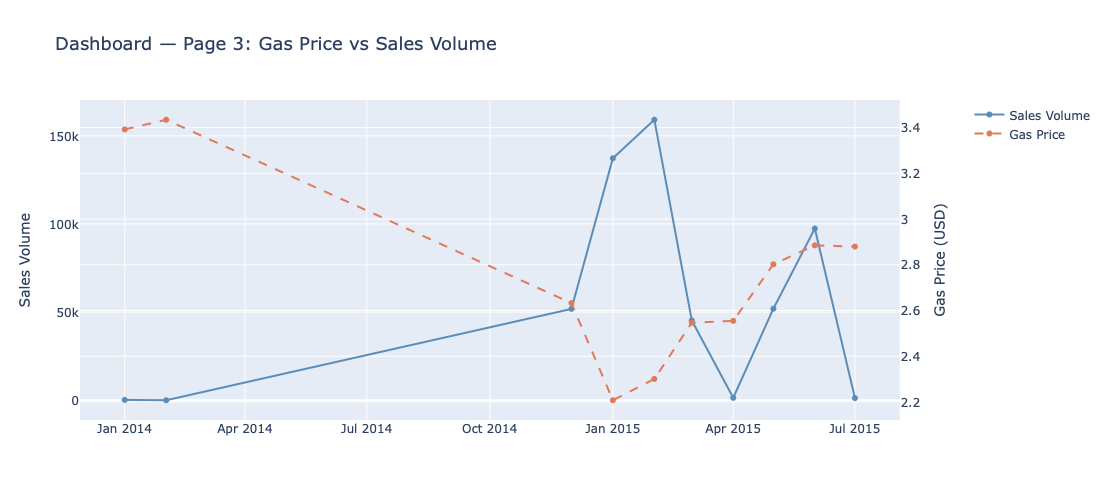

In [4]:
monthly = df.groupby(['year_sold','month']).agg(
    sales_count=('sellingprice','count'),
    avg_gas=('gas_price','mean')
).reset_index()
monthly['date'] = pd.to_datetime(monthly[['year_sold','month']].assign(day=1).rename(
    columns={'year_sold':'year'}))

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=monthly['date'], y=monthly['sales_count'],
    name='Sales Volume', line=dict(color='#5B8DB8', width=2)
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=monthly['date'], y=monthly['avg_gas'],
    name='Gas Price', line=dict(color='#E07B5A', width=2, dash='dash')
), secondary_y=True)

fig.update_layout(
    title_text='Dashboard — Page 3: Gas Price vs Sales Volume',
    title_font_size=18,
    height=500
)
fig.update_yaxes(title_text='Sales Volume', secondary_y=False)
fig.update_yaxes(title_text='Gas Price (USD)', secondary_y=True)
fig.write_html('../outputs/page3_gas_vs_sales.html')
fig.show()

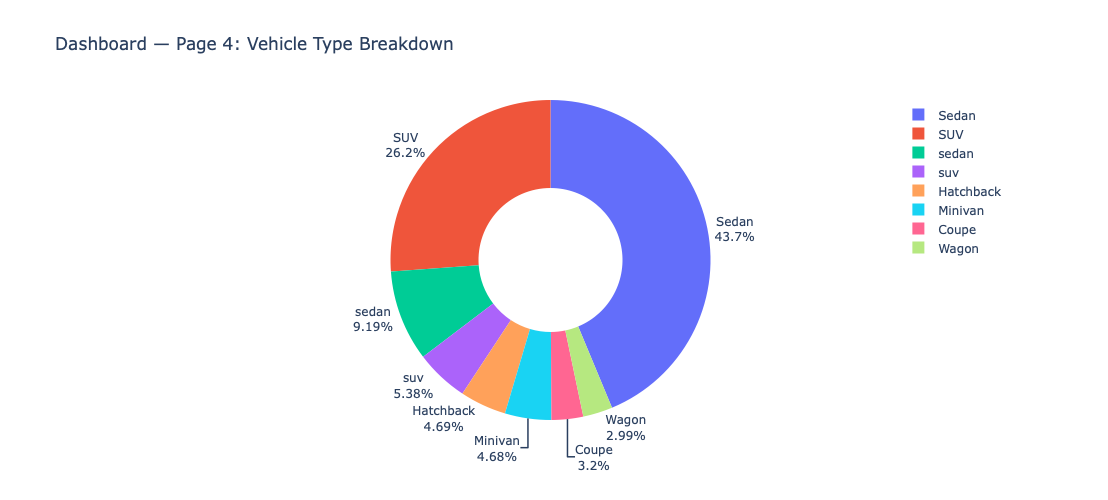

In [5]:
body_counts = df['body'].value_counts().head(8)

fig = px.pie(
    values=body_counts.values,
    names=body_counts.index,
    title='Dashboard — Page 4: Vehicle Type Breakdown',
    hole=0.45,
    height=500
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.write_html('../outputs/page4_vehicle_donut.html')
fig.show()